In [3]:
from google.colab import files

uploaded = files.upload()

Saving Task 2_Global_Superstore_Dataset.zip to Task 2_Global_Superstore_Dataset (1).zip


In [6]:
import os

print("Files currently uploaded:")
print(os.listdir("/content"))

Files currently uploaded:
['.config', 'Task 2_Global_Superstore_Dataset.zip', 'Task 2_Global_Superstore_Dataset (1).zip', 'sample_data']


In [8]:
import os

print("Files currently uploaded:")
print(os.listdir("/content"))

Files currently uploaded:
['.config', 'Task 2_Global_Superstore_Dataset.zip', 'Task 2_Global_Superstore_Dataset (1).zip', 'sample_data']


In [9]:
import glob
import zipfile
import os

# Find the uploaded ZIP file automatically
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")
print(zip_files)

# Use the first ZIP file found
zip_file = zip_files[0]

# Extract it
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/superstore_data")

print("\nDataset extracted successfully!")
print("Files inside:")
print(os.listdir("/content/superstore_data"))

ZIP files found:
['/content/Task 2_Global_Superstore_Dataset.zip', '/content/Task 2_Global_Superstore_Dataset (1).zip']

Dataset extracted successfully!
Files inside:
['train.csv']


In [10]:
import os

print(os.listdir("/content/superstore_data"))

['train.csv']


In [11]:
import pandas as pd
import glob
import os

# Find CSV files inside the extracted folder
csv_files = glob.glob("/content/superstore_data/**/*.csv", recursive=True)

print("CSV file found:")
print(csv_files)

# Load the first CSV
df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

CSV file found:
['/content/superstore_data/train.csv']

Dataset loaded successfully!
Rows: 9800
Columns: 18


In [12]:
# Basic dataset overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(9800, 18)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [13]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Percentage of missing values
print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate Rows:
0

Missing Value Percentage:
Row ID           0.00
Order ID         0.00
Order Date       0.00
Ship Date        0.00
Ship Mode        0.00
Customer ID      0.00
Customer Name    0.00
Segment          0.00
Country          0.00
City             0.00
State            0.00
Postal Code      0.11
Region           0.00
Product ID       0.00
Category         0.00
Sub-Category     0.00
Product Name     0.00
Sales            0.00
dtype: float64


In [14]:
# Descriptive statistics for numerical columns

print("Numerical Summary:")
display(df.describe().T)

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [15]:
# Key business metrics

print("Total Sales:", df["Sales"].sum())
print("Average Sales:", df["Sales"].mean())
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

print("\nTotal Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837
Minimum Sales: 0.444
Maximum Sales: 22638.48

Total Orders: 4922
Total Customers: 793


In [16]:
# Sales by Category

category_sales = (
    df.groupby("Category")["Sales"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

display(category_sales)

,sum,mean,count
Category,,,
Technology,827455.8730,456.401474,1813
Furniture,728658.5757,350.653790,2078
Office Supplies,705422.3340,119.381001,5909


In [19]:
import matplotlib.pyplot as plt

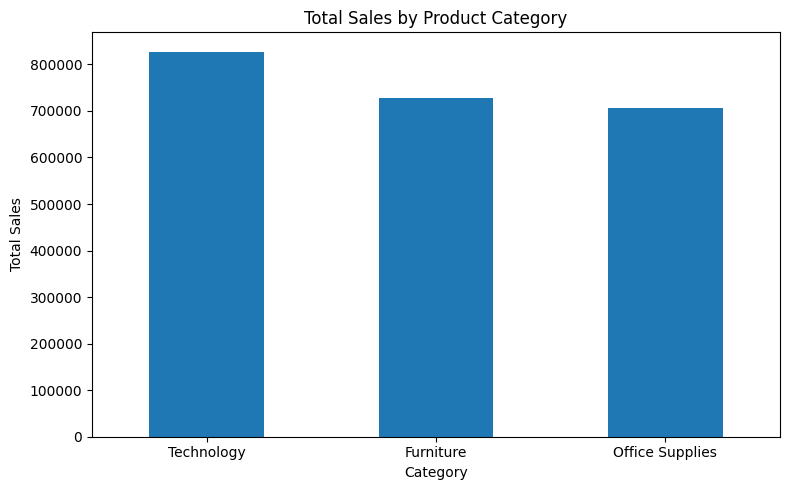

In [20]:
plt.figure(figsize=(8, 5))

category_sales["sum"].plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Sales by Region

region_sales = (
    df.groupby("Region")["Sales"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

display(region_sales)

,sum,mean,count
Region,,,
West,710219.6845,226.184613,3140
East,669518.7260,240.401697,2785
Central,492646.9132,216.357889,2277
South,389151.4590,243.524067,1598


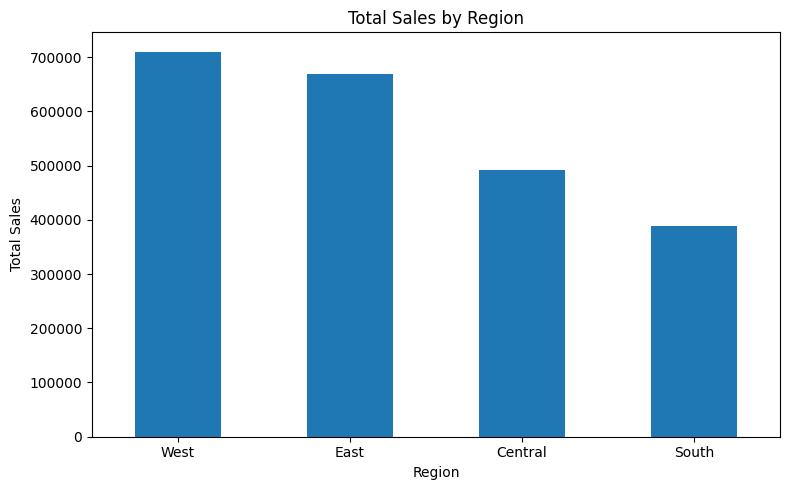

In [22]:
plt.figure(figsize=(8, 5))

region_sales["sum"].plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# Sales by Customer Segment

segment_sales = (
    df.groupby("Segment")["Sales"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

display(segment_sales)

,sum,mean,count
Segment,,,
Consumer,1.148061e+06,225.065777,5101
Corporate,6.884941e+05,233.150720,2953
Home Office,4.249822e+05,243.403309,1746


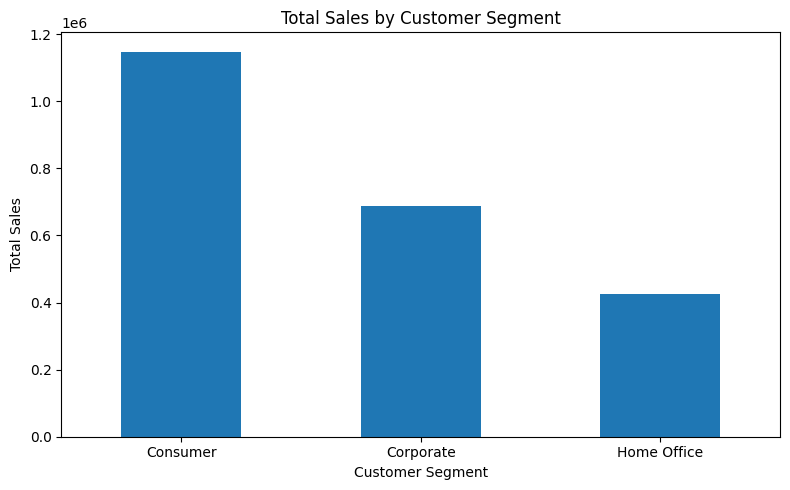

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

segment_sales["sum"].plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Convert Order Date safely
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

print("Date conversion completed!")
print("Missing dates:", df["Order Date"].isna().sum())
print("Date range:", df["Order Date"].min(), "to", df["Order Date"].max())

Date conversion completed!
Missing dates: 0
Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [27]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

display(monthly_sales)

,Sales
Order Date,
2015-01,14205.7070
2015-02,4519.8920
2015-03,55205.7970
2015-04,27906.8550
2015-05,23644.3030
2015-06,34322.9356
2015-07,33781.5430
2015-08,27117.5365
2015-09,81623.5268


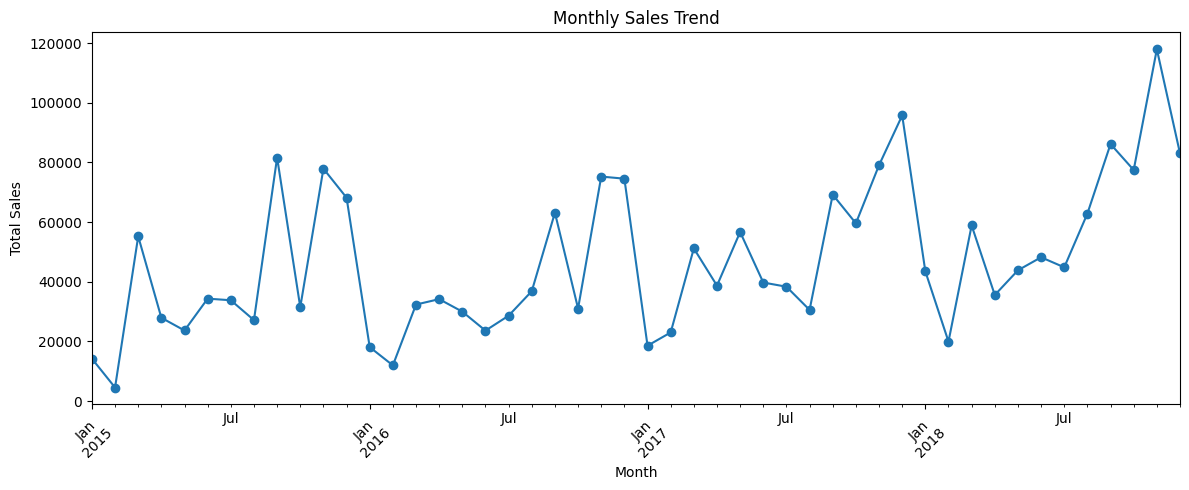

In [28]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

display(monthly_sales)

,Sales
Order Date,
2015-01,14205.7070
2015-02,4519.8920
2015-03,55205.7970
2015-04,27906.8550
2015-05,23644.3030
2015-06,34322.9356
2015-07,33781.5430
2015-08,27117.5365
2015-09,81623.5268


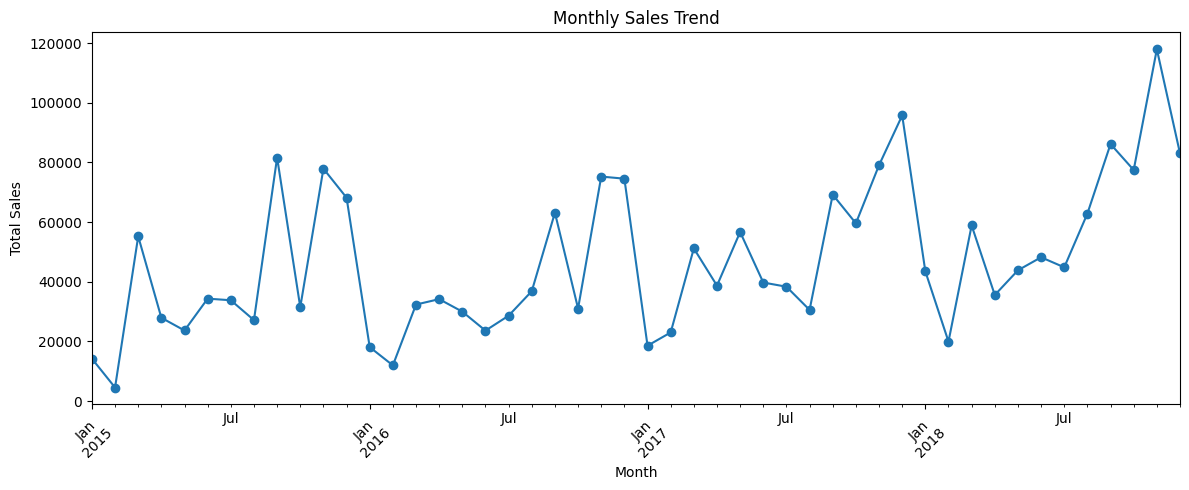

In [30]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Top 10 products by total sales

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_products)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


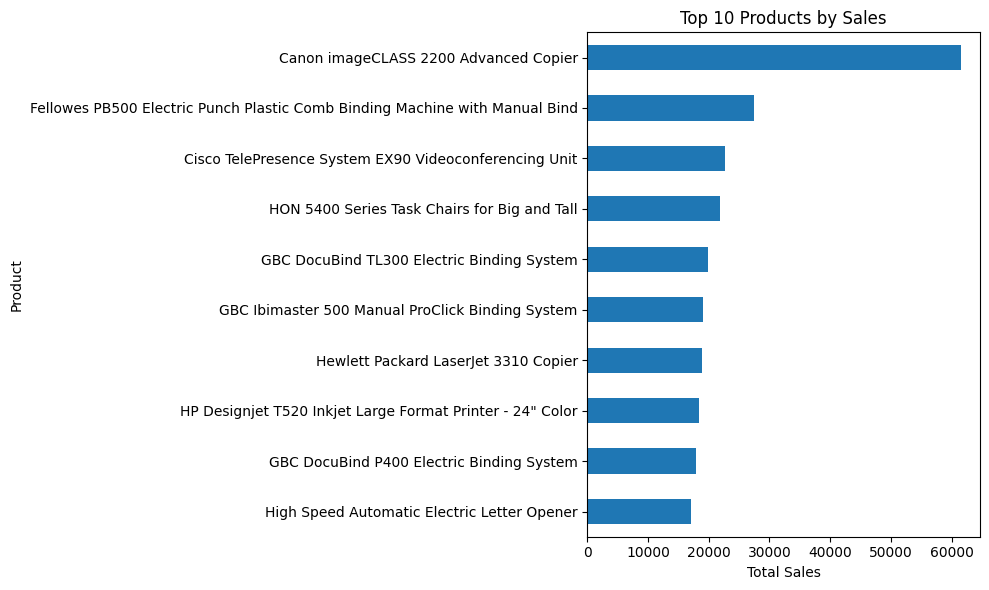

In [32]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [33]:
# Detect outliers in Sales using the IQR method

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Sales Outliers:", len(outliers))

Q1: 17.248
Q3: 210.60500000000002
IQR: 193.35700000000003
Lower Bound: -272.7875000000001
Upper Bound: 500.6405000000001
Number of Sales Outliers: 1145


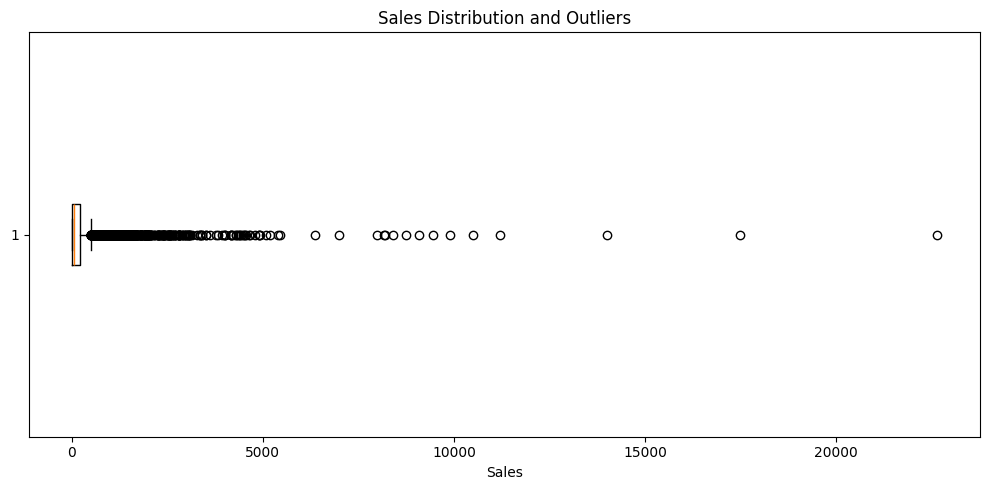

In [34]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Distribution and Outliers")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()

In [35]:
# Correlation between numerical variables

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

display(correlation.round(2))

,Row ID,Postal Code,Sales
Row ID,1.00,0.01,0.00
Postal Code,0.01,1.00,-0.02
Sales,0.00,-0.02,1.00


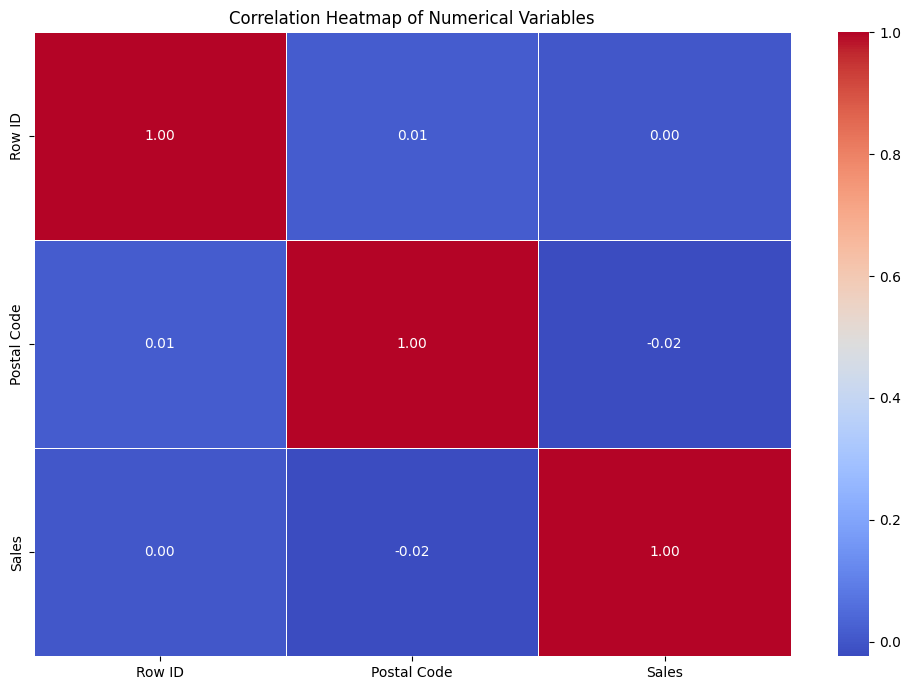

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

# 📊 Final EDA Insights & Business Recommendations

## Key Insights

### 1. Overall Performance
The dataset contains 9,800 transactions with total sales of approximately **$2.26 million**. Average sales per transaction are **$230.77**.

### 2. Category Performance
**Technology** is the leading category with approximately **$827.46K** in sales, followed by Furniture (**$728.66K**) and Office Supplies (**$705.42K**).

### 3. Regional Performance
The **West region** generated the highest sales at approximately **$710.22K**, while the **South region** recorded the lowest at approximately **$389.15K**.

### 4. Customer Segment
The **Consumer segment** contributes the highest sales at approximately **$1.15M**, followed by Corporate and Home Office.

### 5. Monthly Trend
Monthly sales show significant fluctuations and seasonal patterns. The highest monthly sales reach approximately **$120K**, indicating periods of particularly strong demand.

### 6. Top Products
The **Canon imageCLASS 2200 Advanced Copier** is the highest-selling product, generating approximately **$61.60K** in sales.

### 7. Outlier Analysis
Using the IQR method, **1,145 sales records** were identified as potential outliers. These high-value transactions may represent important business opportunities rather than data errors.

### 8. Correlation Analysis
Sales have almost no linear correlation with Row ID (**0.00**) or Postal Code (**-0.02**), indicating that these numerical variables do not meaningfully explain sales variation.

## 💡 Business Recommendations

- Strengthen strategies around the high-performing **Technology** category.
- Investigate the success factors behind the **West region**.
- Develop targeted campaigns to improve **South-region** performance.
- Prioritize the **Consumer segment** through personalized offers.
- Analyze seasonal patterns to improve inventory and marketing planning.
- Maintain availability of high-performing products such as the **Canon imageCLASS 2200 Advanced Copier**.
- Investigate high-value outlier transactions to identify opportunities for premium products and larger orders.

# 📌 Conclusion

This exploratory data analysis provided a comprehensive understanding of sales performance, customer segments, regional trends, product performance, temporal patterns, outliers, and relationships between numerical variables.

The analysis demonstrates how raw business data can be transformed into meaningful insights that support better decision-making.

The findings from this EDA will also serve as the foundation for the **CodeAlpha Task 3 Data Visualization project**.